[info] Model predicted class 1 (dandelion) with prob 1.0000
[info] 44 superpixels (features).
[info] Running KernelExplainer.shap_values for nsamples=1024 ... this may take time.


  0%|          | 0/1 [00:00<?, ?it/s]

[info] SHAP computed in 9.3s


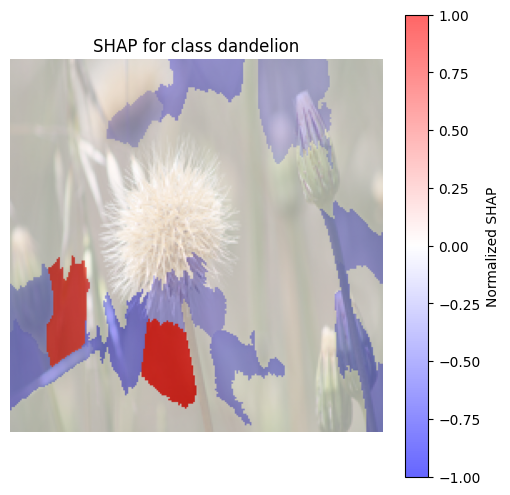

Top superpixels (id, shap): [(171, 8.088729415501625), (81, 6.397719596677778), (176, 4.374422417207406), (101, 4.259934104771592), (36, 3.0976541746576385), (121, 3.0878053194213577), (66, 2.6678677576048315), (116, 2.5984986001789188)]


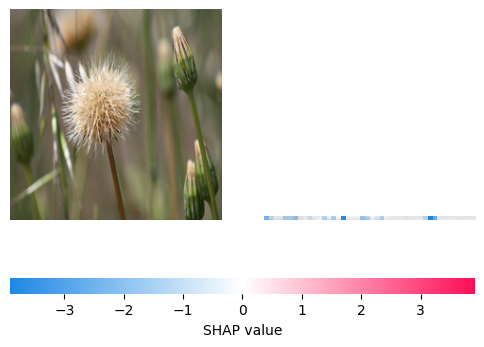

(1, 44, 5) and img matrix shape is : (224, 224, 3)


[info] Model predicted class 0 (daisy) with prob 1.0000
[info] 25 superpixels (features).
[info] Running KernelExplainer.shap_values for nsamples=1024 ... this may take time.


  0%|          | 0/1 [00:00<?, ?it/s]

[info] SHAP computed in 8.2s


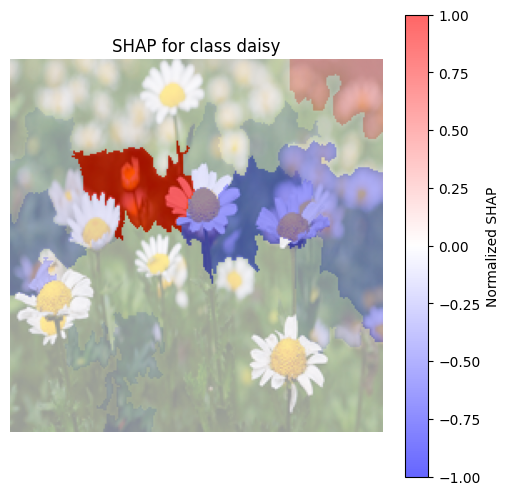

Top superpixels (id, shap): [(60, 12.545214022997168), (105, 12.07285860093031), (10, 8.540848075031231), (45, 6.215989171191901), (75, 5.128869416832333), (80, 4.712094939822081), (55, 3.1147917605226154), (5, 2.8726897836368077)]


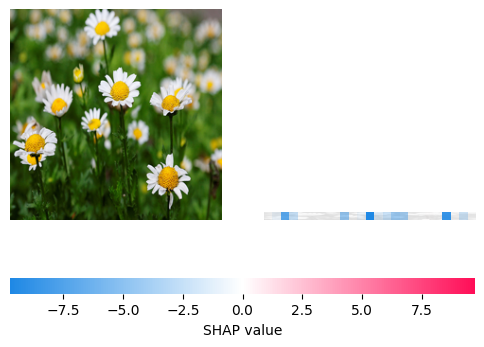

(1, 25, 5) and img matrix shape is : (224, 224, 3)


[info] Model predicted class 2 (rose) with prob 0.9987
[info] 36 superpixels (features).
[info] Running KernelExplainer.shap_values for nsamples=1024 ... this may take time.


  0%|          | 0/1 [00:00<?, ?it/s]

[info] SHAP computed in 9.0s


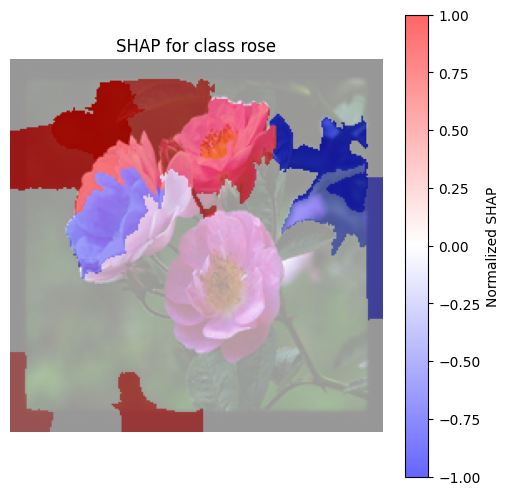

Top superpixels (id, shap): [(57, 3.7836450432093924), (42, 3.02929392813116), (77, 2.869080604389713), (107, 2.1855772320183124), (93, 1.9698278608139286), (117, 1.9254838816310187), (48, 1.9209529494236077), (6, 1.8700041999150905)]


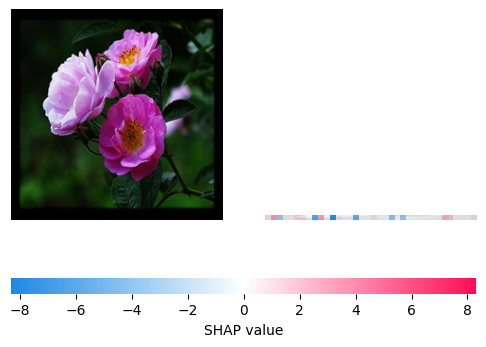

(1, 36, 5) and img matrix shape is : (224, 224, 3)


[info] Model predicted class 3 (sunflower) with prob 1.0000
[info] 26 superpixels (features).
[info] Running KernelExplainer.shap_values for nsamples=1024 ... this may take time.


  0%|          | 0/1 [00:00<?, ?it/s]

[info] SHAP computed in 8.4s


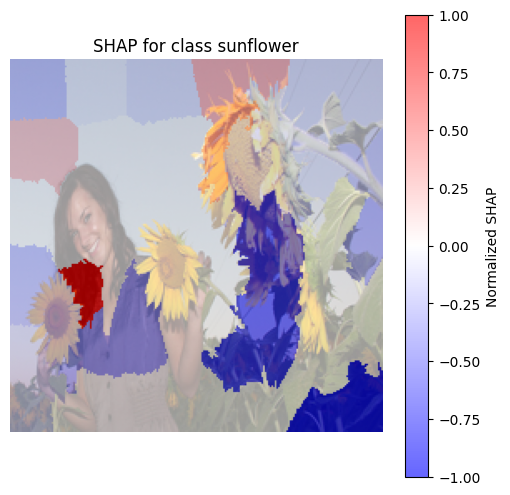

Top superpixels (id, shap): [(28, 7.996952978928871), (73, 6.7402495466013725), (18, 6.512071456566977), (63, 2.9178077503294824), (3, 2.3492407697142936), (68, 2.080662767306687), (93, 1.9640040986293055), (8, 1.6558758147832318)]


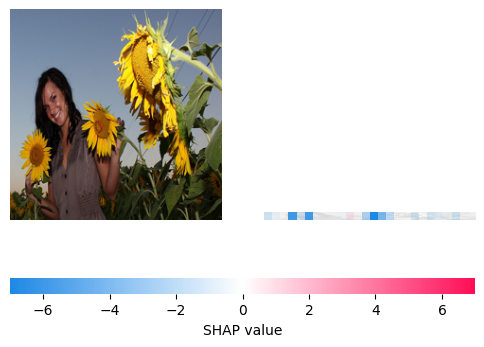

(1, 26, 5) and img matrix shape is : (224, 224, 3)


[info] Model predicted class 4 (tulip) with prob 1.0000
[info] 21 superpixels (features).
[info] Running KernelExplainer.shap_values for nsamples=1024 ... this may take time.


  0%|          | 0/1 [00:00<?, ?it/s]

[info] SHAP computed in 8.2s


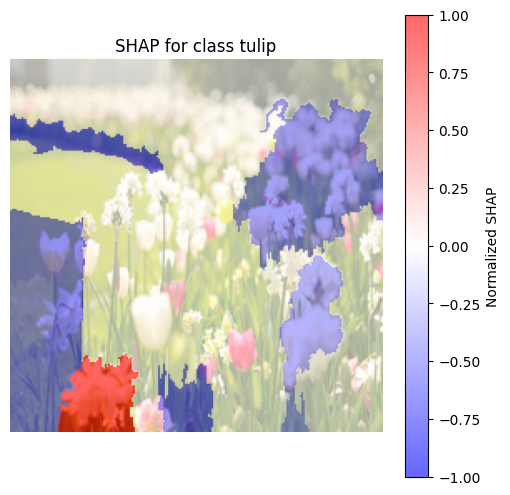

Top superpixels (id, shap): [(64, 1.7246136692248182), (74, 1.6379563663665502), (34, 1.1996174503124495), (49, 1.158735316084703), (69, 0.95317905280287), (24, 0.9054629608786109), (59, 0.8876084744194511), (19, 0.8365437899081426)]


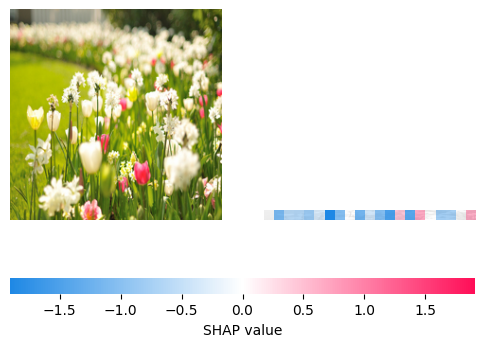

(1, 21, 5) and img matrix shape is : (224, 224, 3)




In [2]:
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import math, time

import torch
import torch.nn.functional as F
from torchvision import models, transforms

import shap
from skimage.segmentation import slic
from skimage.util import img_as_float

IMAGE_PATHS = ["/content/4552571121_2677bcdec3.jpg",
               "/content/3337536080_1db19964fe.jpg",
               "/content/3661675690_ed2d05fa5f_n.jpg",
               "/content/4933230991_d50c0f7c66.jpg",
               "/content/5674134129_2db5136cba.jpg"
               ]
               # <-list of paths of images to explain
CHECKPOINT_PATH = "/content/vgg16_flowers_epoch_100.pt"   # <-- change to your checkpoint path
NUM_CLASSES = 5
CLASS_NAMES = ["daisy","dandelion","rose","sunflower","tulip"]
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

N_SEGMENTS = 50       # number of superpixels
NSAMPLES_SHAP = 1024  # number of Kernel SHAP samples (increase for accuracy)
BATCH_SIZE = 32       # model batch size for mask predictions
USE_LOGITS = True     # explain logits (recommended) or probabilities (False)

# -------------------------
# Helpers: model & preprocessing
# -------------------------
preprocess = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

def load_finetuned_vgg16(checkpoint_path, num_classes=3, device=DEVICE):
    model = models.vgg16(pretrained=False)
    in_features = model.classifier[6].in_features
    model.classifier[6] = torch.nn.Linear(in_features, num_classes)
    ckpt = torch.load(checkpoint_path, map_location=device)
    if isinstance(ckpt, dict) and ("model_state_dict" in ckpt or "state_dict" in ckpt):
        state = ckpt.get("model_state_dict", ckpt.get("state_dict"))
    else:
        state = ckpt
    new_state = {}
    for k,v in state.items():
        if k.startswith("module."):
            new_state[k[len("module."):]] = v
        else:
            new_state[k] = v
    model.load_state_dict(new_state, strict=True)
    model.to(device).eval()
    return model

def model_predict_batch_from_uint8_images(model, images_uint8, return_logits=True):
    """
    images_uint8: np.array (N,H,W,3), dtype uint8 (0..255)
    returns: np.array (N, C) logits (if return_logits) else probs
    """
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, images_uint8.shape[0], BATCH_SIZE):
            batch = images_uint8[i:i+BATCH_SIZE]
            tensors = []
            for img in batch:
                pil = Image.fromarray(img)
                tensors.append(preprocess(pil))
            xb = torch.stack(tensors).to(DEVICE)
            logits = model(xb)
            if return_logits:
                preds.append(logits.cpu().numpy())
            else:
                preds.append(F.softmax(logits, dim=1).cpu().numpy())
    return np.vstack(preds)

# -------------------------
# Superpixel segmentation & masking utilities
# -------------------------
def segment_image(pil_image, n_segments=N_SEGMENTS, compactness=10):
    """
    Returns:
      segments: HxW int map (labels 0..M-1)
      image_float: HxWx3 float in [0,1]
    """
    img_resized = pil_image.resize((224,224))
    image = np.array(img_resized).astype(float) / 255.0
    segments = slic(img_as_float(image), n_segments=n_segments, compactness=compactness, start_label=0)
    return segments, image

def mask_image_with_superpixels(image_float, segments, mask_bool, background_color=None):
    """
    image_float: HxWx3 float [0,1]
    mask_bool: length M boolean array. True => KEEP that superpixel; False => replace by background
    background_color: 3-vector float [0,1] or None -> use mean color
    returns uint8 image (H,W,3) in 0..255 (uint8)
    """
    H,W,_ = image_float.shape
    out = image_float.copy()
    if background_color is None:
        bg = image_float.mean(axis=(0,1))
    else:
        bg = np.array(background_color).reshape(1,1,3)
    M = mask_bool.shape[0]
    for s in range(M):
        if not mask_bool[int(s)]:
            out[segments == s] = bg
    out = np.clip(out, 0.0, 1.0)
    return (out * 255).astype(np.uint8)

# -------------------------
# Build a predict function that maps mask vectors -> model outputs
# -------------------------
def make_mask_predict_fn(model, image_float, segments, background_color=None, return_logits=USE_LOGITS):
    """
    Returns a function f(masks_array) -> np.array (N, C)
    masks_array: shape (N, M) (0/1 or floats between 0/1)
    """
    M = segments.max() + 1
    if background_color is None:
        background_color = image_float.mean(axis=(0,1))

    def f(masks_array):
        masks_array = np.atleast_2d(masks_array)
        # ensure shape (N, M)
        imgs = np.zeros((masks_array.shape[0], 224, 224, 3), dtype=np.uint8)
        for i in range(masks_array.shape[0]):
            mask_bool = masks_array[i].astype(bool)
            imgs[i] = mask_image_with_superpixels(image_float, segments, mask_bool, background_color)
        preds = model_predict_batch_from_uint8_images(model, imgs, return_logits=return_logits)
        return preds
    return f

# -------------------------
# Main: run Kernel SHAP on the full-image mask
# -------------------------
def explain_with_kernel_shap(model, pil_image, n_segments=N_SEGMENTS, nsamples=NSAMPLES_SHAP, return_logits=USE_LOGITS):
    segments, image_float = segment_image(pil_image, n_segments=n_segments)
    M = segments.max() + 1
    print(f"[info] {M} superpixels (features).")

    # create predict function
    predict_fn = make_mask_predict_fn(model, image_float, segments, background_color=None, return_logits=return_logits)

    # KernelExplainer background: use baseline mask = all zeros (no superpixels) as representative
    background_masks = np.zeros((1, M))  # one baseline
    explainer = shap.KernelExplainer(predict_fn, background_masks)

    # full image mask (all ones)
    full_mask = np.ones((1, M))

    print(f"[info] Running KernelExplainer.shap_values for nsamples={nsamples} ... this may take time.")
    t0 = time.time()
    shap_values = explainer.shap_values(full_mask, nsamples=nsamples)
    t1 = time.time()
    print(f"[info] SHAP computed in {t1-t0:.1f}s")

    # shap_values format:
    # - For classification with C outputs: shap_values is a list of length C, each element shape (1, M)
    # - For single-output: shap_values is array (1, M)
    return {
        "shap_values": shap_values,
        "segments": segments,
        "image_float": image_float
    }

# -------------------------
# Visualization: map shap values to pixel heatmap and overlay
# -------------------------
def shap_values_to_heatmap(shap_vals_for_class, segments, image_float, normalize=True):
    H,W,_ = image_float.shape
    heat = np.zeros((H,W), dtype=float)
    for i,val in enumerate(shap_vals_for_class.ravel()):
        heat[segments == i] = val
    if normalize:
        m = np.max(np.abs(heat)) + 1e-12
        heat = heat / m
    return heat

def plot_overlay(pil_image, heatmap, alpha=0.6, cmap='bwr', title=None):
    plt.figure(figsize=(6,6))
    img = np.array(pil_image.resize((224,224))).astype(float) / 255.0
    plt.imshow(img)
    plt.imshow(heatmap, cmap=cmap, alpha=alpha, vmin=-1, vmax=1)
    plt.colorbar(label='Normalized SHAP')
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

if __name__ == "__main__":

  for IMAGE_PATH in IMAGE_PATHS:
      if not os.path.exists(IMAGE_PATH):
         raise FileNotFoundError(f"Image not found: {IMAGE_PATH}")
      if not os.path.exists(CHECKPOINT_PATH):
          raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")

      pil = Image.open(IMAGE_PATH).convert("RGB")
      model = load_finetuned_vgg16(CHECKPOINT_PATH, num_classes=NUM_CLASSES, device=DEVICE)

      # determine model's prediction on original image
      orig_uint8 = np.array(pil.resize((224,224))).astype(np.uint8)[np.newaxis,...]

      pred = model_predict_batch_from_uint8_images(model, orig_uint8, return_logits=USE_LOGITS)[0]
      if USE_LOGITS:
          probs = F.softmax(torch.from_numpy(pred), dim=0).numpy()
      else:
          probs = pred
      pred_class = int(np.argmax(probs))
      print(f"[info] Model predicted class {pred_class} ({CLASS_NAMES[pred_class]}) with prob {probs[pred_class]:.4f}")


      res = explain_with_kernel_shap(model, pil, n_segments=N_SEGMENTS, nsamples=NSAMPLES_SHAP, return_logits=USE_LOGITS)
      shap_vals = res["shap_values"]
      segments = res["segments"]
      image_float = res["image_float"]

      # select shap values for predicted class (if multioutput)
      if isinstance(shap_vals, list) and len(shap_vals) == NUM_CLASSES:
          sv_class = shap_vals[pred_class]  # shape (1, M)
      else:
          # single-output array (1, M)
          sv_class = np.array(shap_vals).reshape(1,-1)

      heat = shap_values_to_heatmap(sv_class, segments, image_float, normalize=True)
      plot_overlay(pil, heat, alpha=0.6, title=f"SHAP for class {CLASS_NAMES[pred_class]}")
      # Optionally print top superpixels
      seg_vals = sv_class.ravel()
      topk = np.argsort(seg_vals)[-8:][::-1]
      print("Top superpixels (id, shap):", [(int(i), float(seg_vals[i])) for i in topk])

      img = np.array(pil.resize((224,224))).astype(float) / 255.0

      shap.image_plot(shap_vals, img)

      # shap.summary_plot(shap_vals, img)
      print(f"{shap_vals.shape} and img matrix shape is : {img.shape}")
      print('\n')

    # cannot be made for images as we cannot distictly identify features that directly contribute to the
    # classfification of an image
    # shap.waterfall_plot(shap_vals[:])

    # shap.decision_plot(
    #     explainer.expected_value[0],
    #     shap_values[0].values.flatten(),
    #     feature_names=[f"Pixel {i}" for i in range(shap_values[0].values.size)]
    # )

In [ ]:
pred = model_predict_batch_from_uint8_images(model, orig_uint8, return_logits=USE_LOGITS)
p = F.softmax(torch.from_numpy(pred),dim = 0).numpy()
print(p)
print(pred)

[[1. 1. 1. 1. 1.]]
[[-17.381449   39.93911   -20.13171   -18.082592  -10.9502945]]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Done.
Done.
Predicted class: 1 (dandelion), orig prob: 1.0000
Base value: -1.764541, Full-image value: 38.053341
Sum SHAP ~ 37.576608, base + sum ~ 35.812067


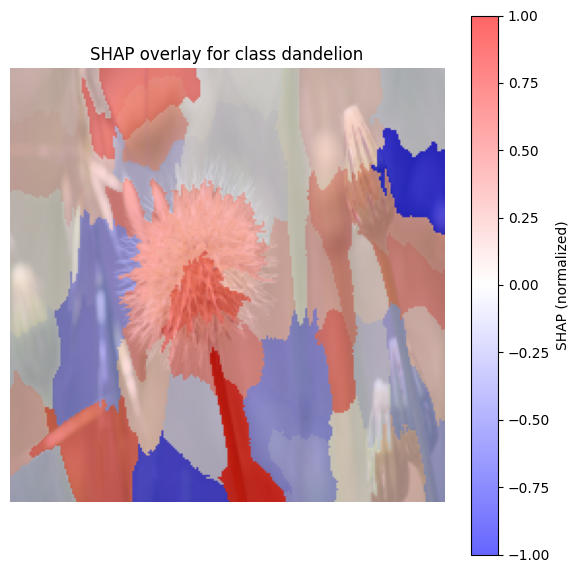

Done.
Done.
Predicted class: 0 (daisy), orig prob: 1.0000
Base value: -1.833044, Full-image value: 57.305717
Sum SHAP ~ 55.619439, base + sum ~ 53.786394


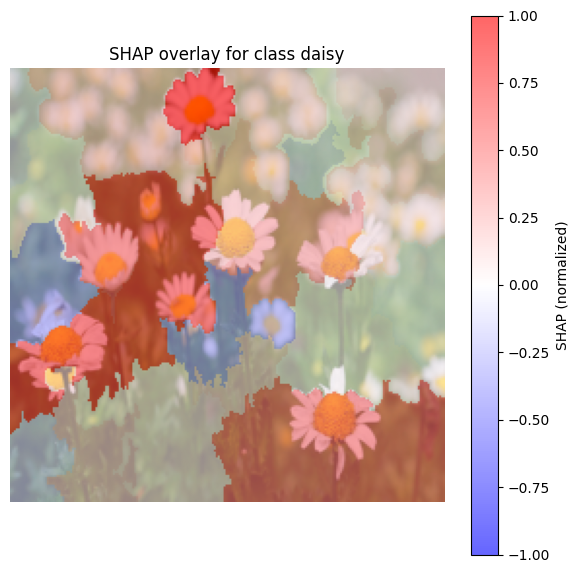

Done.
Done.
Predicted class: 2 (rose), orig prob: 0.9998
Base value: 1.736991, Full-image value: 8.335586
Sum SHAP ~ 7.049975, base + sum ~ 8.786965


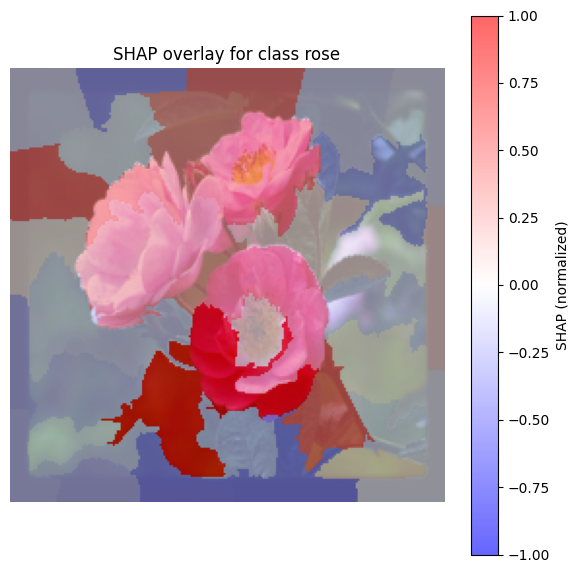

Done.
Done.
Predicted class: 3 (sunflower), orig prob: 1.0000
Base value: -2.731223, Full-image value: 33.266853
Sum SHAP ~ 35.013379, base + sum ~ 32.282156


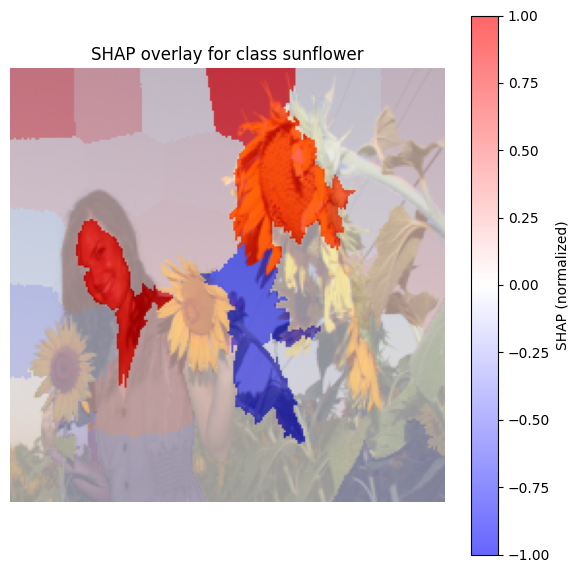

Done.
Done.
Predicted class: 4 (tulip), orig prob: 0.9994
Base value: 0.032526, Full-image value: 7.261082
Sum SHAP ~ 5.845906, base + sum ~ 5.878432


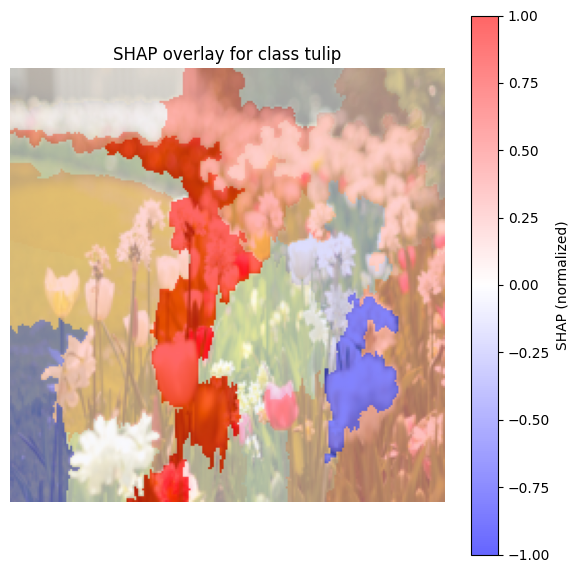

In [3]:
import os
import math
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F
from torchvision import models, transforms

from skimage.segmentation import slic
from skimage.util import img_as_float


CHECKPOINT_PATH = "/content/vgg16_flowers_epoch_100.pt"   # <-- change to your checkpoint path
NUM_CLASSES = 5
CLASS_NAMES = ["daisy","dandelion","rose","sunflower","tulip"]  # adjust if different
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------
# Preprocessing (VGG default)
# ----------------------
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

to_numpy = transforms.Compose([
    transforms.Resize((224, 224)),
])

# ----------------------
# Model load helper (finetuned VGG16)
# ----------------------
def load_finetuned_vgg16(checkpoint_path, num_classes=3, device=DEVICE):
    """
    Load VGG16 and adapt classifier to num_classes, then load checkpoint state_dict.
    Accepts either full model state_dict or a dict with 'model_state_dict' key.
    """
    model = models.vgg16(pretrained=False)  # don't load imagenet weights; we'll load checkpoint
    # Replace final classifier layer (classifier[6] in torchvision's VGG)
    in_features = model.classifier[6].in_features
    model.classifier[6] = torch.nn.Linear(in_features, num_classes)

    # load checkpoint
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found at {checkpoint_path}.")
    ckpt = torch.load(checkpoint_path, map_location=device)

    # Try different checkpoint structures
    if isinstance(ckpt, dict) and "model_state_dict" in ckpt:
        state = ckpt["model_state_dict"]
    elif isinstance(ckpt, dict) and "state_dict" in ckpt:
        state = ckpt["state_dict"]
    else:
        state = ckpt

    # If keys were saved with 'module.' prefix (DataParallel), strip it
    new_state = {}
    for k, v in state.items():
        if k.startswith("module."):
            new_state[k[len("module."):]] = v
        else:
            new_state[k] = v

    model.load_state_dict(new_state, strict=True)
    model.to(device).eval()
    return model

# ----------------------
# Superpixel & masking helpers (same as earlier)
# ----------------------
def superpixel_segment(pil_image, n_segments=50, compactness=10):
    image = np.array(to_numpy(pil_image)).astype(float) / 255.0
    segments = slic(img_as_float(image), n_segments=n_segments, compactness=compactness, start_label=0)
    return segments, image

def mask_image_with_superpixels(image, segments, mask, background=None):
    out = image.copy()
    if background is None:
        bg = image.mean(axis=(0,1))
    else:
        bg = np.array(background).reshape(1,1,3)
    for seg_id in range(mask.shape[0]):
        if not mask[seg_id]:
            out[segments == seg_id] = bg
    return out

def model_predict_batch(model, batch_images, return_logits=False):
    """
    batch_images: numpy array (N x H x W x 3) in [0,1]
    returns: logits (N x C) if return_logits True, otherwise softmax probabilities
    """
    model.eval()
    with torch.no_grad():
        tensors = []
        for img in batch_images:
            pil = Image.fromarray((img*255).astype(np.uint8))
            t = preprocess(pil)
            tensors.append(t)
        batch = torch.stack(tensors).to(DEVICE)
        logits = model(batch)
        if return_logits:
            return logits.cpu().numpy()
        probs = F.softmax(logits, dim=1).cpu().numpy()
    return probs

# Kernel SHAP weight and mask generation (same)
def kernel_shap_weight(M, s):
    if s == 0 or s == M:
        return 1e-6
    comb = math.comb(M, s)
    return (M - 1) / (comb * s * (M - s))

def generate_masks_random(M, nsamples, seed=None):
    rng = np.random.default_rng(seed)
    masks = np.zeros((nsamples, M), dtype=bool)
    for i in range(nsamples):
        s = rng.integers(1, M)  # avoid extremes
        ones = rng.choice(M, size=s, replace=False)
        masks[i, ones] = True
    return masks

def solve_weighted_ridge(X, y, weights, l2_reg=1e-6):
    W = weights.reshape(-1)
    WX = X * W[:, None]
    A = X.T @ WX
    reg = l2_reg * np.eye(A.shape[0])
    reg[0,0] = 0.0
    A += reg
    b = np.linalg.solve(A, X.T @ (W * y))
    return b

# ----------------------
# Kernel SHAP main adapted for finetuned model
# ----------------------
def kernel_shap_image(model, pil_image, nsamples=800, n_superpixels=50, compactness=10,
                      target_class=None, batch_size=64, seed=None, l2_reg=1e-6,
                      background=None, explain_logits=False):
    """
    explain_logits: if True, uses logits as target y (recommended when model trained with logits).
    Otherwise uses softmax probabilities (0..1).
    """
    model = model.to(DEVICE)
    model.eval()

    segments, image = superpixel_segment(pil_image, n_segments=n_superpixels, compactness=compactness)
    M = segments.max() + 1
    if background is None:
        background = image.mean(axis=(0,1))

    # Determine target class using model on original image
    orig_logits = model_predict_batch(model, np.expand_dims(image, axis=0), return_logits=True)[0]
    orig_probs = torch.softmax(torch.from_numpy(orig_logits), dim=0).numpy()
    top_pred = int(np.argmax(orig_probs))
    if target_class is None:
        target_class = top_pred

    # Generate masks and append empty + full for baseline/full
    masks = generate_masks_random(M, nsamples, seed=seed)
    special = np.vstack([np.zeros((1,M), dtype=bool), np.ones((1,M), dtype=bool)])
    masks = np.vstack([masks, special])
    nsamples_total = masks.shape[0]

    # Create masked images
    masked_images = []
    for i in range(nsamples_total):
        mi = mask_image_with_superpixels(image, segments, masks[i], background=background)
        mi = np.clip(mi, 0.0, 1.0)
        masked_images.append((mi * 255).astype(np.uint8))
    masked_images = np.array(masked_images)

    # Predict (logits or probs)
    preds = []
    for i in range(0, nsamples_total, batch_size):
        batch = masked_images[i:i+batch_size].astype(np.uint8)
        batch_float = batch.astype(float)/255.0
        if explain_logits:
            p = model_predict_batch(model, batch_float, return_logits=True)
        else:
            p = model_predict_batch(model, batch_float, return_logits=False)
        preds.append(p)
    preds = np.vstack(preds)
    if explain_logits:
        y = preds[:, target_class]            # logits
    else:
        y = preds[:, target_class]            # probabilities

    # Regression matrix
    X = np.concatenate([np.ones((nsamples_total, 1)), masks.astype(float)], axis=1)
    s_counts = masks.sum(axis=1)
    weights = np.array([kernel_shap_weight(M, int(s)) for s in s_counts])

    coef = solve_weighted_ridge(X, y, weights, l2_reg=l2_reg)
    base_value = coef[0]
    shap_values = coef[1:]
    full_val = y[-1]  # last is full mask
    return {
        "shap_values": shap_values,
        "segments": segments,
        "base_value": base_value,
        "full_value": full_val,
        "predicted_class": target_class,
        "orig_probs": orig_probs,
        "image": image
    }

# ----------------------
# Visualization
# ----------------------
def shap_to_heatmap(shap_values, segments, image, normalize=True):
    H, W, _ = image.shape
    heat = np.zeros((H, W), dtype=float)
    for i, val in enumerate(shap_values):
        heat[segments == i] = val
    if normalize:
        maxabs = np.max(np.abs(heat)) + 1e-12
        heat = heat / maxabs
    return heat

def plot_shap_overlay(pil_image, heatmap, alpha=0.6, cmap='bwr', title=None):
    plt.figure(figsize=(7,7))
    img = np.array(to_numpy(pil_image)).astype(float) / 255.0
    plt.imshow(img)
    plt.imshow(heatmap, cmap=cmap, alpha=alpha, vmin=-1, vmax=1)
    plt.colorbar(label='SHAP (normalized)')
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

if __name__ == "__main__":
  # List of IMAGES for inference and analaysis from the test set -->

    IMAGE_PATHS = ["/content/4552571121_2677bcdec3.jpg",
               "/content/3337536080_1db19964fe.jpg",
               "/content/3661675690_ed2d05fa5f_n.jpg",
               "/content/4933230991_d50c0f7c66.jpg",
               "/content/5674134129_2db5136cba.jpg"
               ]

    for IMAGE_PATH in IMAGE_PATHS:
      if not os.path.exists(IMAGE_PATH):
         raise FileNotFoundError(f"Put an image at {IMAGE_PATH} or change IMAGE_PATH.")

      pil = Image.open(IMAGE_PATH).convert("RGB")

      # Load your finetuned VGG16
      vgg = load_finetuned_vgg16(CHECKPOINT_PATH, num_classes=NUM_CLASSES, device=DEVICE)

      # Run Kernel SHAP (using logits is usually better for classification explanations)
      print("Done.")
      result = kernel_shap_image(vgg, pil_image=pil,
                                nsamples=700,
                                n_superpixels=50,
                                compactness=10,
                                target_class=None,
                                batch_size=64,
                                seed=42,
                                l2_reg=1e-6,
                                background=None,
                                explain_logits=True)

      shap_vals = result["shap_values"]
      segments = result["segments"]
      base_val = result["base_value"]
      full_val = result["full_value"]
      predicted_class = result["predicted_class"]
      orig_probs = result["orig_probs"]
      print("Done.")
      print(f"Predicted class: {predicted_class} ({CLASS_NAMES[predicted_class]}), orig prob: {orig_probs[predicted_class]:.4f}")
      print(f"Base value: {base_val:.6f}, Full-image value: {full_val:.6f}")
      print(f"Sum SHAP ~ {shap_vals.sum():.6f}, base + sum ~ {base_val + shap_vals.sum():.6f}")

      heat = shap_to_heatmap(shap_vals, segments, result["image"], normalize=True)
      plot_shap_overlay(pil, heat, alpha=0.6, title=f"SHAP overlay for class {CLASS_NAMES[predicted_class]}")